# ScamSense — 03: Multilingual Scam Classification (Modelling)

**Purpose:** Fine-tune XLM-RoBERTa (primary) and mBERT (baseline) for binary scam detection across 5 languages. Track experiments with MLflow on DagsHub. Evaluate with per-language F1, precision, recall, and AUC.

**Setup before running:**
1. Upload `train.csv`, `val.csv`, `test.csv` as a Kaggle Dataset 
2. Add `DAGSHUB_TOKEN` and `HF_TOKEN` to Kaggle Secrets (Add-ons → Secrets)
3. Enable GPU: Settings → Accelerator → GPU T4 x1
4. Enable internet: Settings → Internet → On

**Input:** Kaggle dataset `/kaggle/input/scamsense-data/`  
**Output:** Models saved to `/kaggle/working/` then downloaded

| Cell | Description |
|---|---|
| 1 | Install dependencies |
| 2 | MLflow + DagsHub config |
| 3 | Load and tokenise datasets |
| 4 | Model factory |
| 5 | Training loop |
| 6 | Per-language evaluation |
| 7 | Train + evaluate XLM-RoBERTa |
| 8 | Train + evaluate mBERT baseline |
| 9 | Compare models |
| 10 | Save best model + push to HuggingFace Hub |

In [10]:
# =============================================================================
# CELL 1: Install dependencies
# -----------------------------------------------------------------------------

!pip install -q transformers mlflow dagshub accelerate huggingface_hub

import os
import numpy as np
import pandas as pd
import torch

# Kaggle paths
INPUT_DIR  = '/kaggle/input/datasets/bhoovika/scamscene-processed-dataset'   # your uploaded dataset
OUTPUT_DIR = '/kaggle/working'
MODELS_DIR = f'{OUTPUT_DIR}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [11]:
# =============================================================================
# CELL 2: MLflow + DagsHub configuration
# -----------------------------------------------------------------------------
import mlflow
import dagshub
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
DAGSHUB_TOKEN    = secrets.get_secret('DAGSHUB_TOKEN')
DAGSHUB_USERNAME = 'Bhoovika'

os.environ['MLFLOW_TRACKING_USERNAME'] = DAGSHUB_USERNAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN

dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name='ScamSense',
    mlflow=True,
)
mlflow.set_tracking_uri('https://dagshub.com/Bhoovika/ScamSense.mlflow')
mlflow.set_experiment('scamsense-classification')

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow')

Initialized MLflow to track repo "Bhoovika/ScamSense"

Repository Bhoovika/ScamSense initialized!

MLflow tracking URI: https://dagshub.com/Bhoovika/ScamSense.mlflow
View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow


In [12]:
# =============================================================================
# CELL 3: Load datasets and tokenise
# -----------------------------------------------------------------------------

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MAX_LENGTH = 128
BATCH_SIZE = 32


def load_split(filename):
    kaggle_path  = f'{INPUT_DIR}/{filename}'
    working_path = f'{OUTPUT_DIR}/{filename}'
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path, encoding='utf-8-sig')
    elif os.path.exists(working_path):
        return pd.read_csv(working_path, encoding='utf-8-sig')
    else:
        raise FileNotFoundError(
            f'{filename} not found. Upload train/val/test.csv as a Kaggle Dataset '
            f'named "scamsense-data" and attach it to this notebook.'
        )

df_train = load_split('train.csv').dropna(subset=['text']).reset_index(drop=True)
df_val   = load_split('val.csv').dropna(subset=['text']).reset_index(drop=True)
df_test  = load_split('test.csv').dropna(subset=['text']).reset_index(drop=True)


for df in [df_train, df_val, df_test]:
    df.drop(columns=[c for c in ['strat_key'] if c in df.columns], inplace=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Train label balance: {df_train["label"].value_counts().to_dict()}')


class ScamSenseDataset(Dataset):
    """PyTorch Dataset for tokenised scam/ham messages."""

    def __init__(self, df, tokenizer, max_length=128):
        self.labels = df['label'].tolist()
        self.langs  = df['language'].tolist()
        self.enc    = tokenizer(
            df['text'].tolist(),
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
            'language':       self.langs[idx],
        }


def build_loaders(model_name):
    """Tokenise all splits with the given model's tokeniser."""
    print(f'Tokenising with {model_name}...')
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    train_ds   = ScamSenseDataset(df_train, tokenizer, MAX_LENGTH)
    val_ds     = ScamSenseDataset(df_val,   tokenizer, MAX_LENGTH)
    test_ds    = ScamSenseDataset(df_test,  tokenizer, MAX_LENGTH)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f'Loaders ready: {len(train_loader)} train batches')
    return tokenizer, train_loader, val_loader, test_loader

Train: 94,372 | Val: 20,223 | Test: 20,223
Train label balance: {0: 47186, 1: 47186}


In [13]:
# =============================================================================
# CELL 4: Model factory
# -----------------------------------------------------------------------------
# freeze_encoder=False  → full fine-tune (XLM-RoBERTa primary model)
# freeze_encoder=True   → frozen encoder, head only (mBERT fast baseline)
# =============================================================================
from transformers import AutoModelForSequenceClassification

def build_model(model_name, freeze_encoder=False):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )
    if freeze_encoder:
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'pooler' not in name:
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        print(f'Frozen encoder: {trainable:,} / {total:,} params trainable')
    else:
        total = sum(p.numel() for p in model.parameters())
        print(f'Full fine-tune: {total:,} params trainable')
    return model.to(DEVICE)

In [14]:
# =============================================================================
# CELL 5: Training loop with MLflow logging
# -----------------------------------------------------------------------------
# - AdamW with linear warmup scheduler
# - Mixed precision fp16 via torch.cuda.amp
# - Gradient clipping at 1.0
# - Early stopping on val F1, patience=2
# - Best checkpoint saved to /kaggle/working/models/ after every improvement
# - All hyperparameters and metrics logged to DagsHub MLflow
# - Returns (best_ckpt, history) so training curves can be plotted afterward
# =============================================================================
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score
import time


def train_model(model, model_name, run_name, train_loader, val_loader,
                epochs=3, lr=2e-5, warmup_ratio=0.1, freeze_encoder=False):
    optimizer     = AdamW([p for p in model.parameters() if p.requires_grad],
                          lr=lr, weight_decay=0.01)
    total_steps   = len(train_loader) * epochs
    warmup_steps  = int(total_steps * warmup_ratio)
    scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler        = torch.cuda.amp.GradScaler()
    loss_fn       = nn.CrossEntropyLoss()
    best_val_f1   = 0.0
    best_ckpt     = f'{MODELS_DIR}/{run_name}_best.pt'
    no_improve    = 0
    patience      = 2

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            'model_name': model_name, 'freeze_encoder': freeze_encoder,
            'epochs': epochs, 'learning_rate': lr, 'batch_size': BATCH_SIZE,
            'max_length': MAX_LENGTH, 'warmup_ratio': warmup_ratio,
            'train_size': len(df_train), 'val_size': len(df_val),
        })

        for epoch in range(epochs):
            # Training
            model.train()
            train_loss = 0.0
            t0 = time.time()
            for batch in train_loader:
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                lbls = batch['labels'].to(DEVICE)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    loss = loss_fn(model(input_ids=ids, attention_mask=mask).logits, lbls)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                train_loss += loss.item()

            # Validation
            model.eval()
            val_loss, all_preds, all_labels = 0.0, [], []
            with torch.no_grad():
                for batch in val_loader:
                    ids  = batch['input_ids'].to(DEVICE)
                    mask = batch['attention_mask'].to(DEVICE)
                    lbls = batch['labels'].to(DEVICE)
                    with torch.cuda.amp.autocast():
                        out  = model(input_ids=ids, attention_mask=mask)
                        loss = loss_fn(out.logits, lbls)
                    val_loss += loss.item()
                    all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
                    all_labels.extend(lbls.cpu().numpy())

            avg_train = train_loss / len(train_loader)
            avg_val   = val_loss   / len(val_loader)
            val_f1    = f1_score(all_labels, all_preds, average='weighted')
            val_acc   = accuracy_score(all_labels, all_preds)
            elapsed   = time.time() - t0

            print(f'Epoch {epoch+1}/{epochs} | Train Loss: {avg_train:.4f} | '
                  f'Val Loss: {avg_val:.4f} | Val F1: {val_f1:.4f} | '
                  f'Val Acc: {val_acc:.4f} | Time: {elapsed:.0f}s')

            history['train_loss'].append(avg_train)
            history['val_loss'].append(avg_val)
            history['val_f1'].append(val_f1)
            history['val_acc'].append(val_acc)

            mlflow.log_metrics({'train_loss': avg_train, 'val_loss': avg_val,
                                'val_f1': val_f1, 'val_acc': val_acc}, step=epoch)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(model.state_dict(), best_ckpt)
                print(f'  ✓ Best checkpoint saved (val F1: {val_f1:.4f})')
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch+1}')
                    break

        mlflow.log_metric('best_val_f1', best_val_f1)
        mlflow.log_artifact(best_ckpt)

    print(f'Training done. Best Val F1: {best_val_f1:.4f}')
    print(f'Checkpoint: {best_ckpt}')
    return best_ckpt, history

In [15]:
# =============================================================================
# CELL 6: Per-language evaluation function
# -----------------------------------------------------------------------------
# Computes overall + per-language: accuracy, F1, precision, recall, AUC, loss.
# Also generates confusion matrix and per-language performance plots.
# =============================================================================
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score, classification_report, confusion_matrix
)

def evaluate_model(model, test_loader, run_name, model_name):
    model.eval()
    all_preds, all_probs, all_labels, all_langs = [], [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for batch in test_loader:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            with torch.cuda.amp.autocast():
                out  = model(input_ids=ids, attention_mask=mask)
                loss = F.cross_entropy(out.logits, labels)
            total_loss += loss.item()
            n_batches  += 1
            probs = F.softmax(out.logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(out.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_langs.extend(batch['language'])

    avg_test_loss = round(total_loss / n_batches, 4)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    def metrics_dict(labels, preds, probs, lang):
        try:
            auc = round(roc_auc_score(labels, probs), 4)
        except ValueError:
            auc = None
        return {
            'model':     run_name,
            'language':  lang,
            'accuracy':  round(accuracy_score(labels, preds), 4),
            'f1':        round(f1_score(labels, preds, average='weighted'), 4),
            'precision': round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
            'recall':    round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
            'auc':       auc,
        }

    overall = metrics_dict(all_labels, all_preds, all_probs, 'overall')
    overall['loss'] = avg_test_loss

    print(f'\n=== {run_name} — TEST SET ===')
    print(f'  loss      : {avg_test_loss}')
    for k, v in overall.items():
        if k not in ('model', 'language', 'loss'):
            print(f'  {k:10s}: {v}')
    print()
    print(classification_report(all_labels, all_preds, target_names=['Ham', 'Scam']))

    results = [overall]
    print('--- Per-language ---')
    for lang in sorted(set(all_langs)):
        idx = np.array([i for i, l in enumerate(all_langs) if l == lang])
        m   = metrics_dict(all_labels[idx], all_preds[idx], all_probs[idx], lang)
        results.append(m)
        print(f'  {lang:10s}: Acc={m["accuracy"]}  F1={m["f1"]}  P={m["precision"]}  R={m["recall"]}  AUC={m["auc"]}')

    # --- CONFUSION MATRIX -----------------------------------------------------
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Scam'], yticklabels=['Ham', 'Scam'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{run_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{run_name}_confusion_matrix.png', dpi=150)
    plt.show()

    # --- PER-LANGUAGE F1 BAR CHART --------------------------------------------
    lang_results = results[1:]
    langs   = [r['language'] for r in lang_results]
    f1s     = [r['f1'] for r in lang_results]
    accs    = [r['accuracy'] for r in lang_results]

    x = np.arange(len(langs))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width/2, f1s, width, label='F1', color='#3b82f6')
    ax.bar(x + width/2, accs, width, label='Accuracy', color='#93c5fd')
    ax.set_xticks(x)
    ax.set_xticklabels(langs)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title(f'{run_name} — Per-language Performance')
    ax.legend()
    for i, (f1v, accv) in enumerate(zip(f1s, accs)):
        ax.text(i - width/2, f1v + 0.02, f'{f1v:.2f}', ha='center', fontsize=8)
        ax.text(i + width/2, accv + 0.02, f'{accv:.2f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{run_name}_per_language_performance.png', dpi=150)
    plt.show()

    # Log to MLflow
    with mlflow.start_run(run_name=f'{run_name}_eval'):
        mlflow.log_param('model_name', model_name)
        for k, v in overall.items():
            if k not in ('model', 'language') and v is not None:
                mlflow.log_metric(f'test_{k}', v)
        for r in results[1:]:
            for metric in ('f1', 'precision', 'recall', 'auc', 'accuracy'):
                if r[metric] is not None:
                    mlflow.log_metric(f'test_{metric}_{r["language"]}', r[metric])

    return pd.DataFrame(results)

MODEL: xlm-roberta-base  |  RUN: xlmroberta-scamsense

[1/4] Building data loaders...
Tokenising with xlm-roberta-base...
Loaders ready: 2950 train batches
  Train batches: 2950 | Train samples: 94372
  Val batches:   632 | Val samples:   20223
  Test batches:  632 | Test samples:  20223

[2/4] Building model...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full fine-tune: 278,045,186 params trainable
  Total parameters:     278,045,186
  Trainable parameters: 278,045,186 (100.0%)

[3/4] Starting training...
  Epochs: 3 | LR: 2e-5 | Freeze encoder: False
  Track at: https://dagshub.com/Bhoovika/ScamSense.mlflow



...

/tmp/ipykernel_58/252757713.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/252757713.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/3 | Train Loss: 0.0365 | Val Loss: 0.0339 | Val F1: 0.9920 | Val Acc: 0.9920 | Time: 867s
  ✓ Best checkpoint saved (val F1: 0.9920)


/tmp/ipykernel_58/252757713.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/252757713.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3/3 | Train Loss: 0.0158 | Val Loss: 0.0360 | Val F1: 0.9932 | Val Acc: 0.9932 | Time: 862s
  ✓ Best checkpoint saved (val F1: 0.9932)
🏃 View run xlmroberta-scamsense at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/7b5338f1b440469593815eaa4818d508
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
Training done. Best Val F1: 0.9932
Checkpoint: /kaggle/working/models/xlmroberta-scamsense_best.pt

  Training complete in 44.9 min (2694s)
  Checkpoint saved to: /kaggle/working/models/xlmroberta-scamsense_best.pt


ValueError: x, y, and format string must not be None

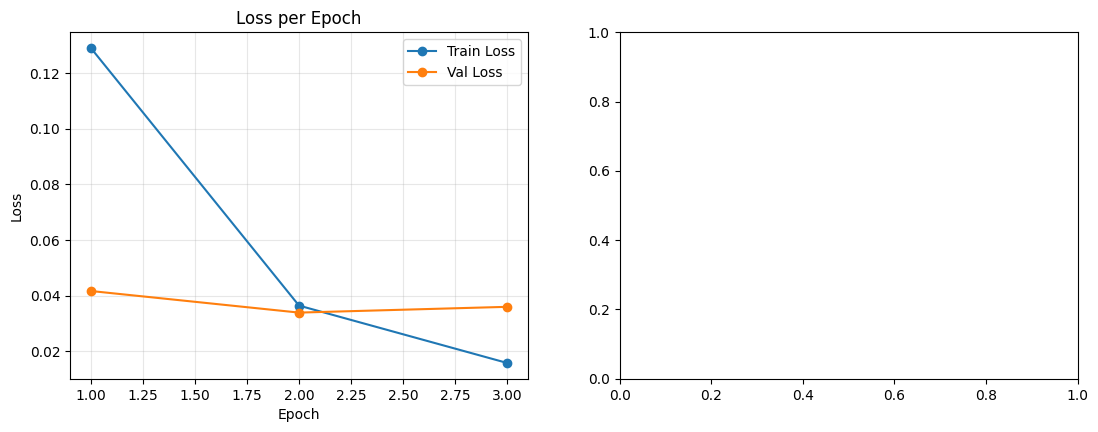

In [16]:
# =============================================================================
# CELL 7: Train and evaluate XLM-RoBERTa (primary model)
# -----------------------------------------------------------------------------
# Full fine-tune: all 278M parameters updated.
# =============================================================================
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

XLM_MODEL_NAME = 'xlm-roberta-base'
XLM_RUN_NAME   = 'xlmroberta-scamsense'

print('=' * 70)
print(f'MODEL: {XLM_MODEL_NAME}  |  RUN: {XLM_RUN_NAME}')
print('=' * 70)

print(f'\n[1/4] Building data loaders...')
xlm_tokenizer, xlm_train_loader, xlm_val_loader, xlm_test_loader = build_loaders(XLM_MODEL_NAME)
print(f'  Train batches: {len(xlm_train_loader)} | Train samples: {len(xlm_train_loader.dataset)}')
print(f'  Val batches:   {len(xlm_val_loader)} | Val samples:   {len(xlm_val_loader.dataset)}')
print(f'  Test batches:  {len(xlm_test_loader)} | Test samples:  {len(xlm_test_loader.dataset)}')

print(f'\n[2/4] Building model...')
xlm_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
total_params = sum(p.numel() for p in xlm_model.parameters())
trainable_params = sum(p.numel() for p in xlm_model.parameters() if p.requires_grad)
print(f'  Total parameters:     {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

print(f'\n[3/4] Starting training...')
print(f'  Epochs: 3 | LR: 2e-5 | Freeze encoder: False')
print(f'  Track at: https://dagshub.com/Bhoovika/ScamSense.mlflow\n')

train_start = time.time()
XLM_CKPT, xlm_history = train_model(
    model=xlm_model, model_name=XLM_MODEL_NAME, run_name=XLM_RUN_NAME,
    train_loader=xlm_train_loader, val_loader=xlm_val_loader,
    epochs=3, lr=2e-5, freeze_encoder=False,
)
train_duration = time.time() - train_start
print(f'\n  Training complete in {train_duration/60:.1f} min ({train_duration:.0f}s)')
print(f'  Checkpoint saved to: {XLM_CKPT}')

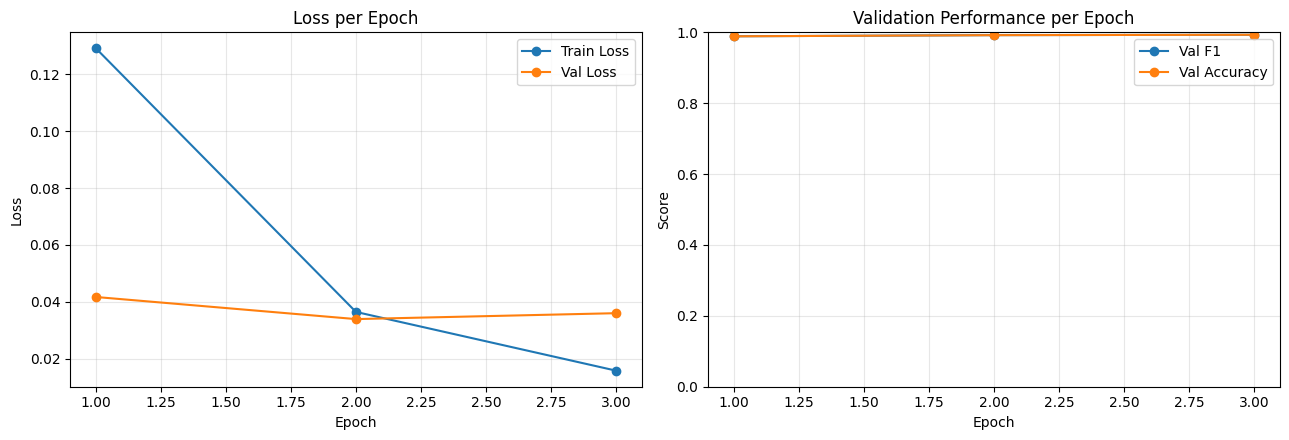


[4/4] Evaluating on test set...


/tmp/ipykernel_58/1347267772.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



=== xlmroberta-scamsense — TEST SET ===
  loss      : 0.0384
  accuracy  : 0.9931
  f1        : 0.9931
  precision : 0.9931
  recall    : 0.9931
  auc       : 0.9992

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99     10111
        Scam       1.00      0.99      0.99     10112

    accuracy                           0.99     20223
   macro avg       0.99      0.99      0.99     20223
weighted avg       0.99      0.99      0.99     20223

--- Per-language ---
  en        : Acc=0.9909  F1=0.9909  P=0.991  R=0.9909  AUC=0.9986
  ms        : Acc=1.0  F1=1.0  P=1.0  R=1.0  AUC=1.0
  singlish  : Acc=0.9964  F1=0.9964  P=0.9964  R=0.9964  AUC=1.0
  ta        : Acc=1.0  F1=1.0  P=1.0  R=1.0  AUC=1.0
  zh        : Acc=0.9993  F1=0.9993  P=0.9993  R=0.9993  AUC=1.0


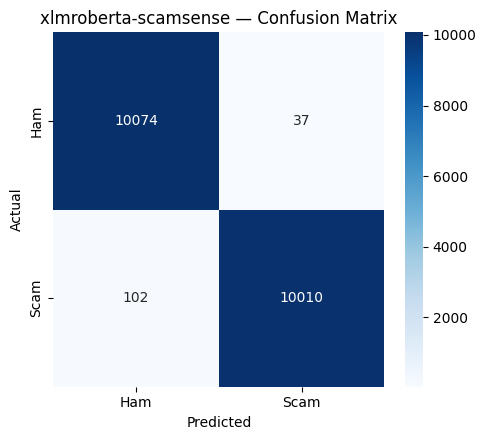

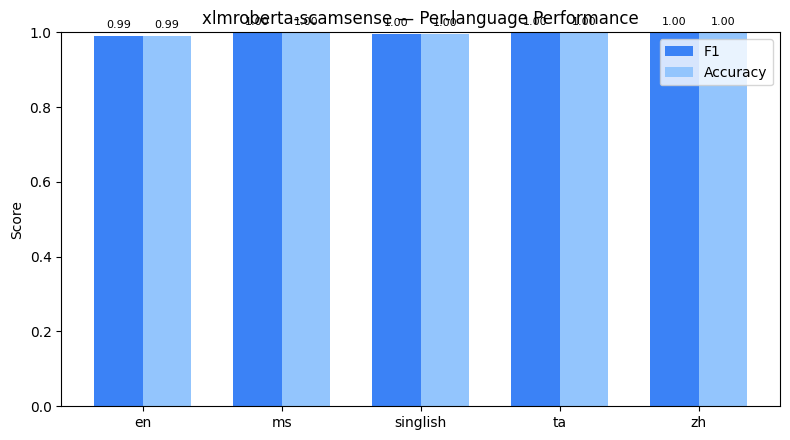

🏃 View run xlmroberta-scamsense_eval at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/2723eb48e4254bb19e6104c3c3872597
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0

  Evaluation complete in 74.5s

TEST RESULTS SUMMARY
               model language  accuracy     f1  precision  recall    auc   loss
xlmroberta-scamsense  overall    0.9931 0.9931     0.9931  0.9931 0.9992 0.0384
xlmroberta-scamsense       en    0.9909 0.9909     0.9910  0.9909 0.9986    NaN
xlmroberta-scamsense       ms    1.0000 1.0000     1.0000  1.0000 1.0000    NaN
xlmroberta-scamsense singlish    0.9964 0.9964     0.9964  0.9964 1.0000    NaN
xlmroberta-scamsense       ta    1.0000 1.0000     1.0000  1.0000 1.0000    NaN
xlmroberta-scamsense       zh    0.9993 0.9993     0.9993  0.9993 1.0000    NaN


In [17]:
# --- TRAINING CURVES -------------------------------------------------------
epochs_range = range(1, len(xlm_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, xlm_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs_range, xlm_history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, xlm_history['val_f1'], marker='o', label='Val F1')
axes[1].plot(epochs_range, xlm_history['val_acc'], marker='o', label='Val Accuracy')
axes[1].set_title('Validation Performance per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{XLM_RUN_NAME}_training_curves.png', dpi=150)
plt.show()

print(f'\n[4/4] Evaluating on test set...')
xlm_model.load_state_dict(torch.load(XLM_CKPT))
xlm_model.eval()

eval_start = time.time()
df_xlm_results = evaluate_model(xlm_model, xlm_test_loader, XLM_RUN_NAME, XLM_MODEL_NAME)
eval_duration = time.time() - eval_start

print(f'\n  Evaluation complete in {eval_duration:.1f}s')
print('\n' + '=' * 70)
print('TEST RESULTS SUMMARY')
print('=' * 70)
print(df_xlm_results.to_string(index=False))
print('=' * 70)

In [18]:
# =============================================================================
# CELL 8: Train and evaluate mBERT (frozen baseline)
# -----------------------------------------------------------------------------
# Frozen encoder: only classification head trained (~1M params).
# Uses higher LR (1e-3) because only the head is updated.
# =============================================================================
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

MBERT_MODEL_NAME = 'bert-base-multilingual-cased'
MBERT_RUN_NAME   = 'mbert-scamsense-baseline'

print('=' * 70)
print(f'MODEL: {MBERT_MODEL_NAME}  |  RUN: {MBERT_RUN_NAME}')
print('=' * 70)

print(f'\n[1/4] Building data loaders...')
mbert_tokenizer, mbert_train_loader, mbert_val_loader, mbert_test_loader = build_loaders(MBERT_MODEL_NAME)
print(f'  Train batches: {len(mbert_train_loader)} | Train samples: {len(mbert_train_loader.dataset)}')
print(f'  Val batches:   {len(mbert_val_loader)} | Val samples:   {len(mbert_val_loader.dataset)}')
print(f'  Test batches:  {len(mbert_test_loader)} | Test samples:  {len(mbert_test_loader.dataset)}')

print(f'\n[2/4] Building model (frozen encoder)...')
mbert_model = build_model(MBERT_MODEL_NAME, freeze_encoder=True)
total_params = sum(p.numel() for p in mbert_model.parameters())
trainable_params = sum(p.numel() for p in mbert_model.parameters() if p.requires_grad)
print(f'  Total parameters:     {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)')

print(f'\n[3/4] Starting mBERT baseline training...')
print(f'  Epochs: 3 | LR: 1e-3 | Freeze encoder: True')
print(f'  Track at: https://dagshub.com/Bhoovika/ScamSense.mlflow\n')

train_start = time.time()
MBERT_CKPT, mbert_history = train_model(
    model=mbert_model, model_name=MBERT_MODEL_NAME, run_name=MBERT_RUN_NAME,
    train_loader=mbert_train_loader, val_loader=mbert_val_loader,
    epochs=3, lr=1e-3, freeze_encoder=True,
)
train_duration = time.time() - train_start
print(f'\n  Training complete in {train_duration/60:.1f} min ({train_duration:.0f}s)')
print(f'  Checkpoint saved to: {MBERT_CKPT}')



MODEL: bert-base-multilingual-cased  |  RUN: mbert-scamsense-baseline

[1/4] Building data loaders...
Tokenising with bert-base-multilingual-cased...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 1/3 | Train Loss: 0.3296 | Val Loss: 0.1968 | Val F1: 0.9218 | Val Acc: 0.9219 | Time: 199s
  ✓ Best checkpoint saved (val F1: 0.9218)


/tmp/ipykernel_58/252757713.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/252757713.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/3 | Train Loss: 0.2319 | Val Loss: 0.1641 | Val F1: 0.9348 | Val Acc: 0.9348 | Time: 216s
  ✓ Best checkpoint saved (val F1: 0.9348)


/tmp/ipykernel_58/252757713.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/252757713.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3/3 | Train Loss: 0.2064 | Val Loss: 0.1541 | Val F1: 0.9399 | Val Acc: 0.9399 | Time: 218s
  ✓ Best checkpoint saved (val F1: 0.9399)
🏃 View run mbert-scamsense-baseline at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/ef13c9088d1146d4a5ac1a25e084ba7d
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
Training done. Best Val F1: 0.9399
Checkpoint: /kaggle/working/models/mbert-scamsense-baseline_best.pt

  Training complete in 11.8 min (708s)
  Checkpoint saved to: /kaggle/working/models/mbert-scamsense-baseline_best.pt


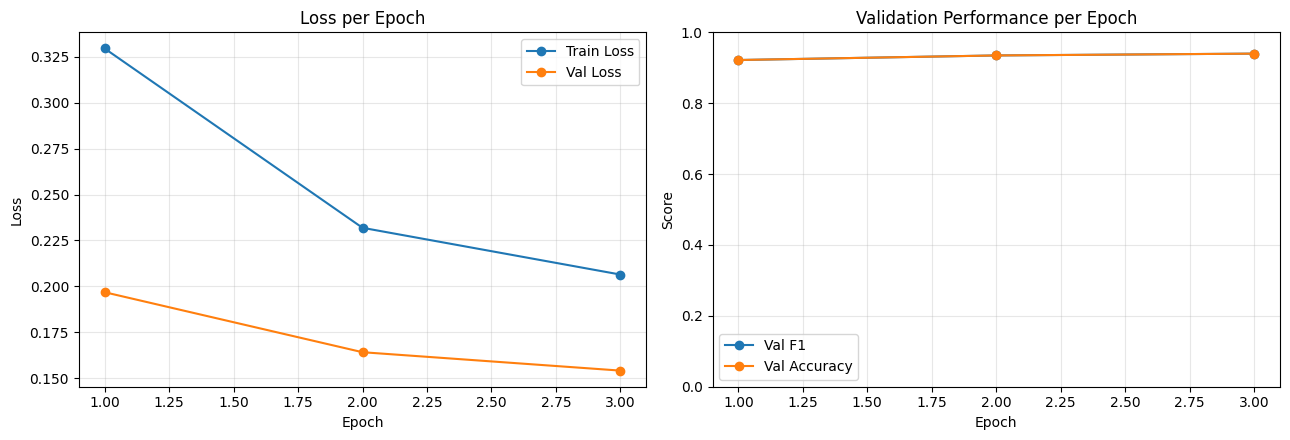


[4/4] Evaluating on test set...


/tmp/ipykernel_58/1347267772.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



=== mbert-scamsense-baseline — TEST SET ===
  loss      : 0.1581
  accuracy  : 0.9382
  f1        : 0.9382
  precision : 0.9382
  recall    : 0.9382
  auc       : 0.9847

              precision    recall  f1-score   support

         Ham       0.94      0.94      0.94     10111
        Scam       0.94      0.94      0.94     10112

    accuracy                           0.94     20223
   macro avg       0.94      0.94      0.94     20223
weighted avg       0.94      0.94      0.94     20223

--- Per-language ---
  en        : Acc=0.9165  F1=0.9165  P=0.9165  R=0.9165  AUC=0.9726
  ms        : Acc=0.9993  F1=0.9993  P=0.9993  R=0.9993  AUC=1.0
  singlish  : Acc=0.9892  F1=0.9892  P=0.9893  R=0.9892  AUC=0.9995
  ta        : Acc=1.0  F1=1.0  P=1.0  R=1.0  AUC=1.0
  zh        : Acc=0.9973  F1=0.9973  P=0.9973  R=0.9973  AUC=0.9996


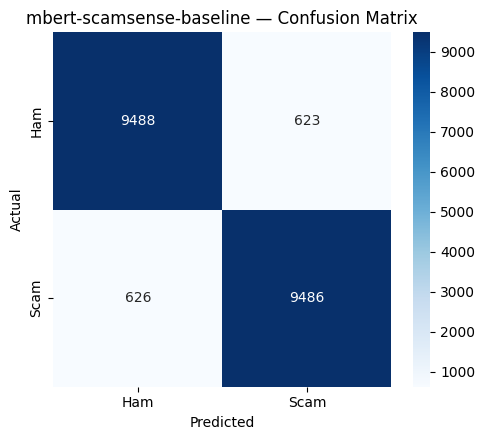

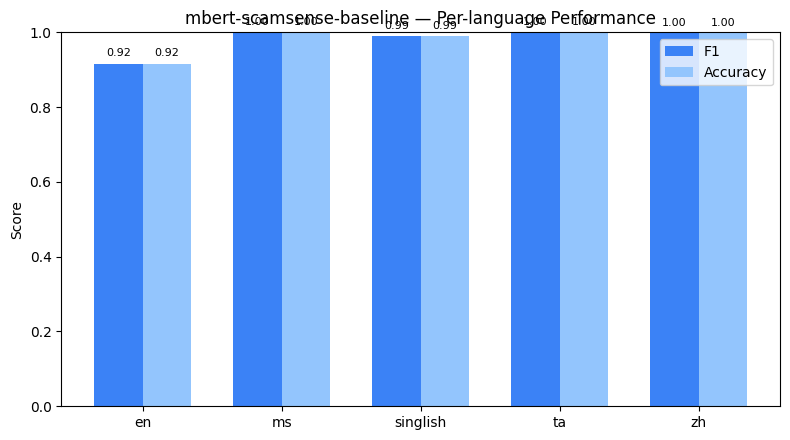

🏃 View run mbert-scamsense-baseline_eval at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/328ccc8405c143b2968c1412962febf8
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0

  Evaluation complete in 66.1s

TEST RESULTS SUMMARY
                   model language  accuracy     f1  precision  recall    auc   loss
mbert-scamsense-baseline  overall    0.9382 0.9382     0.9382  0.9382 0.9847 0.1581
mbert-scamsense-baseline       en    0.9165 0.9165     0.9165  0.9165 0.9726    NaN
mbert-scamsense-baseline       ms    0.9993 0.9993     0.9993  0.9993 1.0000    NaN
mbert-scamsense-baseline singlish    0.9892 0.9892     0.9893  0.9892 0.9995    NaN
mbert-scamsense-baseline       ta    1.0000 1.0000     1.0000  1.0000 1.0000    NaN
mbert-scamsense-baseline       zh    0.9973 0.9973     0.9973  0.9973 0.9996    NaN


In [19]:
# --- TRAINING CURVES -------------------------------------------------------
epochs_range = range(1, len(mbert_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, mbert_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs_range, mbert_history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, mbert_history['val_f1'], marker='o', label='Val F1')
axes[1].plot(epochs_range, mbert_history['val_acc'], marker='o', label='Val Accuracy')
axes[1].set_title('Validation Performance per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MBERT_RUN_NAME}_training_curves.png', dpi=150)
plt.show()

print(f'\n[4/4] Evaluating on test set...')
mbert_model.load_state_dict(torch.load(MBERT_CKPT))
mbert_model.eval()

eval_start = time.time()
df_mbert_results = evaluate_model(mbert_model, mbert_test_loader, MBERT_RUN_NAME, MBERT_MODEL_NAME)
eval_duration = time.time() - eval_start

print(f'\n  Evaluation complete in {eval_duration:.1f}s')
print('\n' + '=' * 70)
print('TEST RESULTS SUMMARY')
print('=' * 70)
print(df_mbert_results.to_string(index=False))
print('=' * 70)

Full results table:
                   model language  accuracy     f1  precision  recall    auc   loss
    xlmroberta-scamsense  overall    0.9931 0.9931     0.9931  0.9931 0.9992 0.0384
    xlmroberta-scamsense       en    0.9909 0.9909     0.9910  0.9909 0.9986    NaN
    xlmroberta-scamsense       ms    1.0000 1.0000     1.0000  1.0000 1.0000    NaN
    xlmroberta-scamsense singlish    0.9964 0.9964     0.9964  0.9964 1.0000    NaN
    xlmroberta-scamsense       ta    1.0000 1.0000     1.0000  1.0000 1.0000    NaN
    xlmroberta-scamsense       zh    0.9993 0.9993     0.9993  0.9993 1.0000    NaN
mbert-scamsense-baseline  overall    0.9382 0.9382     0.9382  0.9382 0.9847 0.1581
mbert-scamsense-baseline       en    0.9165 0.9165     0.9165  0.9165 0.9726    NaN
mbert-scamsense-baseline       ms    0.9993 0.9993     0.9993  0.9993 1.0000    NaN
mbert-scamsense-baseline singlish    0.9892 0.9892     0.9893  0.9892 0.9995    NaN
mbert-scamsense-baseline       ta    1.0000 1.0000     1

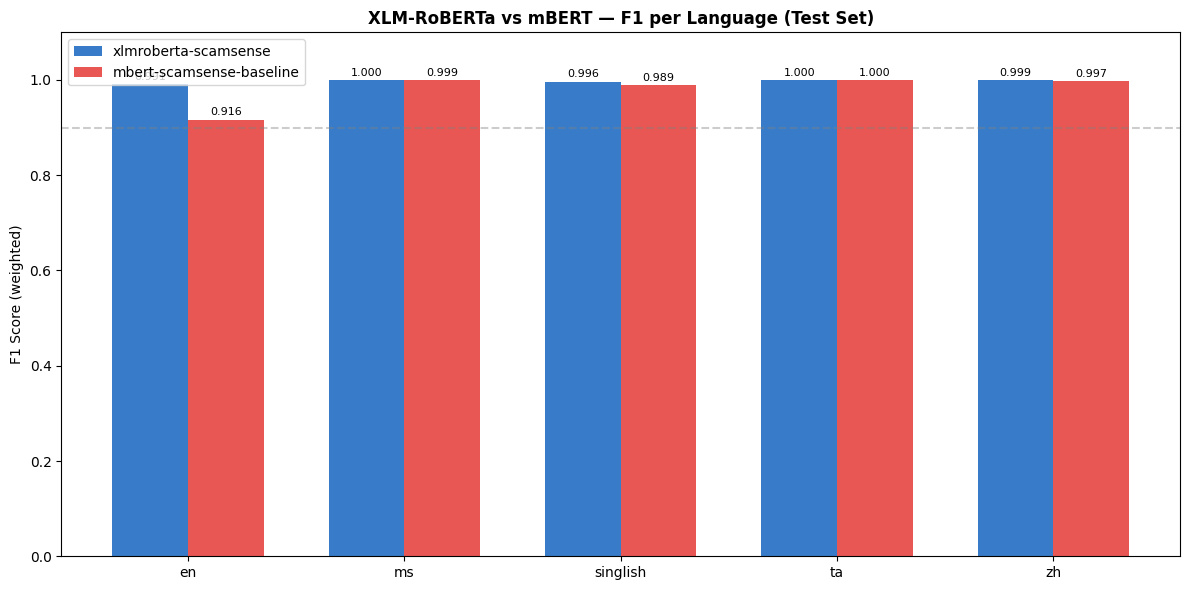

Saved: model_comparison_f1.png

✓ Best model: xlmroberta-scamsense (F1: 0.9931)


In [20]:
# =============================================================================
# CELL 9: Compare models — table and F1 bar chart
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

df_all = pd.concat([df_xlm_results, df_mbert_results], ignore_index=True)

# Save results table
results_path = f'{OUTPUT_DIR}/model_comparison.csv'
df_all.to_csv(results_path, index=False)
print('Full results table:')
print(df_all.to_string(index=False))

# F1 per language chart
df_lang   = df_all[df_all['language'] != 'overall'].copy()
languages = sorted(df_lang['language'].unique())
models    = df_lang['model'].unique()
x = np.arange(len(languages))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1565C0', '#E53935']
for i, (model, color) in enumerate(zip(models, colors)):
    f1_vals = [
        df_lang[(df_lang['model'] == model) & (df_lang['language'] == lang)]['f1'].values[0]
        if len(df_lang[(df_lang['model'] == model) & (df_lang['language'] == lang)]) > 0 else 0
        for lang in languages
    ]
    bars = ax.bar(x + i*w - w/2, f1_vals, width=w, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('XLM-RoBERTa vs mBERT — F1 per Language (Test Set)', fontweight='bold')
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_f1.png')

# Best model
df_overall      = df_all[df_all['language'] == 'overall']
best_model_name = df_overall.loc[df_overall['f1'].idxmax(), 'model']
best_f1         = df_overall['f1'].max()
print(f'\n✓ Best model: {best_model_name} (F1: {best_f1})')

In [21]:
# =============================================================================
# CELL 10: Save best model to /kaggle/working + push to HuggingFace Hub
# -----------------------------------------------------------------------------
# HuggingFace Hub push creates a public model card at:
#   https://huggingface.co/Bhoovika/scamsense-xlmroberta
# =============================================================================
from huggingface_hub import login

# Select best model
if best_model_name == XLM_RUN_NAME:
    best_model, best_tokenizer = xlm_model, xlm_tokenizer
    best_ckpt_path, hf_model_id = XLM_CKPT, 'Bhoovika/scamsense-xlmroberta'
else:
    best_model, best_tokenizer = mbert_model, mbert_tokenizer
    best_ckpt_path, hf_model_id = MBERT_CKPT, 'Bhoovika/scamsense-mbert'

# Load best weights
best_model.load_state_dict(torch.load(best_ckpt_path))
best_model.eval()

# Save to /kaggle/working/models/scamsense_best_model/
save_path = f'{MODELS_DIR}/scamsense_best_model'
os.makedirs(save_path, exist_ok=True)
best_model.save_pretrained(save_path)
best_tokenizer.save_pretrained(save_path)
print(f'Model saved to: {save_path}')
print('Download from Kaggle output panel -> models/scamsense_best_model/')

# Push to HuggingFace Hub
try:
    HF_TOKEN = secrets.get_secret('HF_TOKEN')
    login(token=HF_TOKEN)
    best_model.push_to_hub(hf_model_id)
    best_tokenizer.push_to_hub(hf_model_id)
    print(f'Pushed to: https://huggingface.co/{hf_model_id}')
except Exception as e:
    print(f'HF push skipped — add HF_TOKEN to Kaggle Secrets to enable.')
    print(f'Error: {e}')

print(f'\n✅ Notebook 03 complete.')
print(f'Best model: {best_model_name} | F1: {best_f1}')
print(f'MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/models/scamsense_best_model
Download from Kaggle output panel -> models/scamsense_best_model/


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to: https://huggingface.co/Bhoovika/scamsense-xlmroberta

✅ Notebook 03 complete.
Best model: xlmroberta-scamsense | F1: 0.9931
MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow
